In [1]:
import json
import datetime
import pandas as pd
from os import listdir
from os.path import isfile, join
from IPython.display import Image

from arcgis.gis import GIS
from arcgis.geocoding import geocode
from arcgis.features.use_proximity import plan_routes
from arcgis.features.summarize_data import join_features

import piexif
from watson_developer_cloud import VisualRecognitionV3

In [2]:
threshold = 0.16

In [3]:
gis = GIS('https://deldev.maps.arcgis.com', 'deldev', 'P@ssw0rd@123')
visual_recognition = VisualRecognitionV3('2016-05-20', api_key='f135ee67e833d45e90e2304608e0376b5a148688')

In [4]:
def is_broken(filepath):
    with open(filepath, 'rb') as images_file:
        car_results = visual_recognition.classify(images_file=images_file,
                                                  threshold=0.1,
                                                  classifier_ids=['Insulators_1714265970'])
        classes = car_results['images'][0]['classifiers'][0]['classes']
        for cls in classes:
            if cls['class'] == 'broken':
                if float(cls['score']) > threshold:
                    return True
                
        return False

In [5]:
def get_location(filename):

    exif_dict = piexif.load(filename)

    for tag in exif_dict['GPS']:
        name = piexif.TAGS['GPS'][tag]["name"]
        value = exif_dict['GPS'][tag]

        if name == 'GPSLatitudeRef':
            gps_latitude_ref = value
        elif name == 'GPSLongitudeRef':
            gps_longitude_ref = value
        elif name == 'GPSLatitude':
            gps_latitude = value
        elif name == 'GPSLongitude':
            gps_longitude = value
            
    lat = _convert_to_degress(gps_latitude)
    if gps_latitude_ref != b'N':
        lat = 0 - lat

    lon = _convert_to_degress(gps_longitude)
    if gps_longitude_ref != b'E':
        lon = 0 - lon
        
    return lon, lat

def _convert_to_degress(val):
    """
    Helper function to convert the GPS coordinates stored in the EXIF to degress in float format
    :param value:
    :type value: exifread.utils.Ratio
    :rtype: float
    """
    d = float(val[0][0]) / float(val[0][1])
    m = float(val[1][0]) / float(val[1][1])
    s = float(val[2][0]) / float(val[2][1])
    
    return d + (m / 60.0) + (s / 3600.0)

In [6]:
img = r'C:\xc\Presentations\GeoPython\Watson\insulators\150362.JPG'

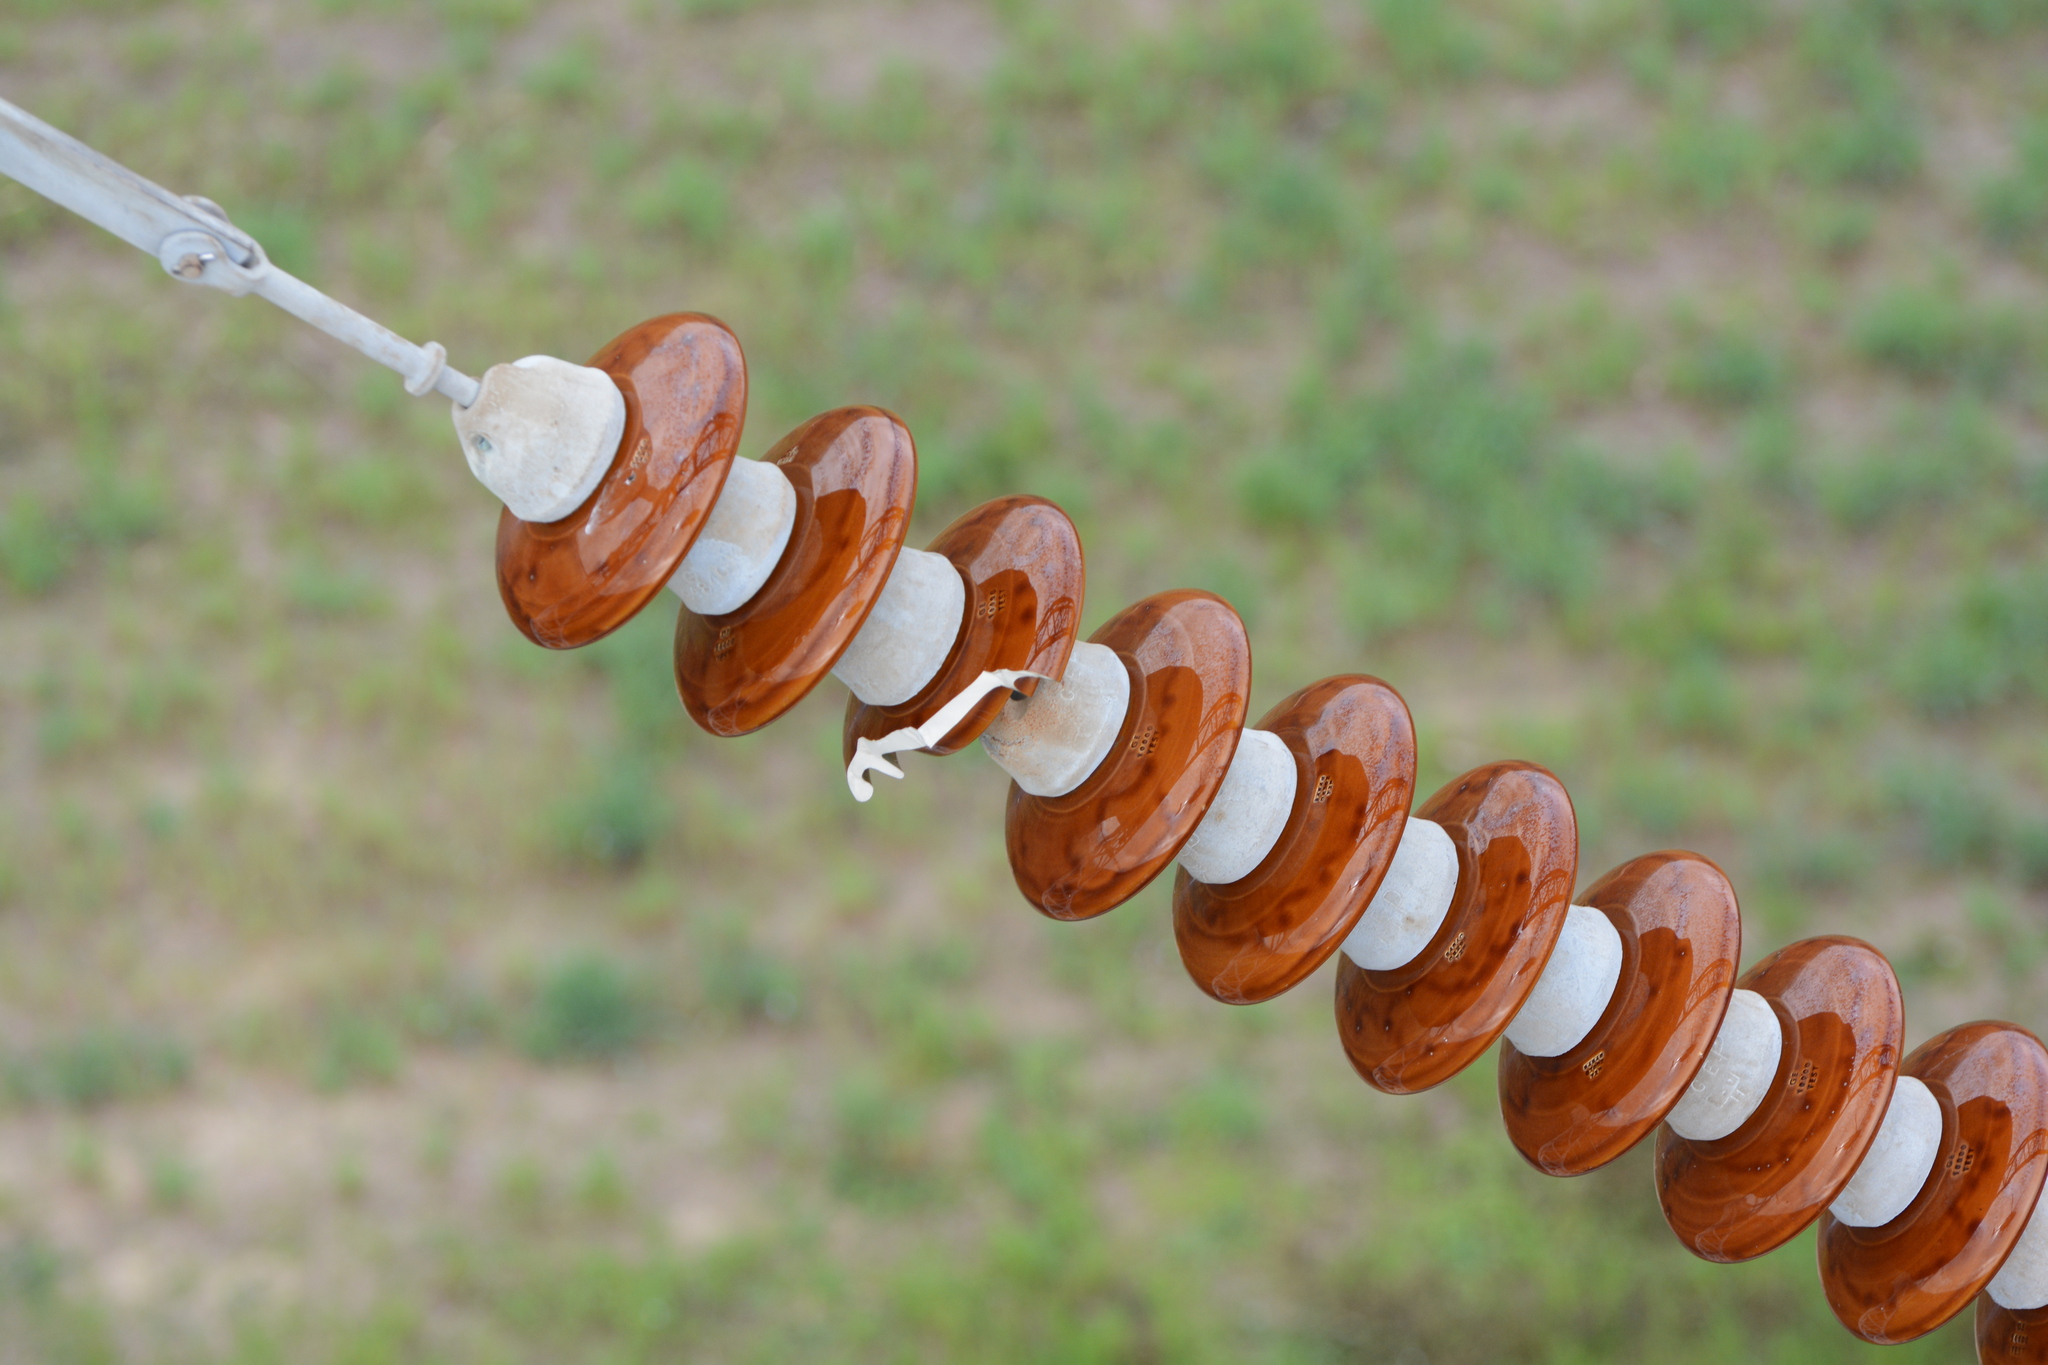

In [7]:
Image(img)

In [8]:
get_location(img)

(-123.05857389997222, 44.698829929999995)

In [9]:
is_broken(img)

True

<Item title:"BPA_TransmissionStructures" type:Feature Service owner:BPA_Publish>
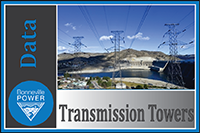

In [10]:
towers = gis.content.search('BPA_TransmissionStructures', 'Feature Layer', outside_org=True)[0]
towers

In [11]:
m = gis.map('Salem, OR')

In [12]:
m

In [13]:
start_location = geocode('2715 Tepper Ln NE, Keizer, OR 97303')[0]
m.draw(start_location, {"title": "Start location", "content": "Bonneville Power Administration"})

start_time = datetime.datetime(2017, 5, 31, 9, 0)

In [14]:
locations = []
path = r'C:\xc\Presentations\GeoPython\Watson\insulators'
for file in listdir(path):
    filepath = path + '\\' + file
    if is_broken(filepath):
        locations.append(get_location(filepath))   
        
df = pd.DataFrame.from_records(locations)
df.columns = ['x', 'y']
broken_insulators = gis.content.import_data(df)

destinations = join_features(broken_insulators, towers, join_operation="JoinOneToOne",
                             spatial_relationship="withindistance", 
                             spatial_relationship_distance=0.1, 
                             spatial_relationship_distance_units="Miles")

routes = plan_routes(destinations, 2, 15, start_time, start_location, stop_service_time=30)

m.add_layer(routes['routes_layer'])

Input field [OID] was not mapped to a field in the network analysis class "Orders".
Input field [OID] was not mapped to a field in the network analysis class "Depots".


In [15]:
m.add_layer(routes['assigned_stops_layer'])